In [1]:
#Esteban Capetillo Martínez 2178074 IMC
#Examen Medio Curso IA y RN

In [2]:
#PARTE 1
#Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
#Cargar datos con url
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
df = pd.read_csv(url)

In [4]:
#Mostrar ultimas 5 filas del dataset y resumen estadistico descriptivo
print("Ultimas 5 filas")
print(df.tail(5))
print("Resumen estadistico descriptivo")
print(df.describe())

Ultimas 5 filas
       carat        cut color clarity  depth  table  price     x     y     z
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64
Resumen estadistico descriptivo
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.700

In [5]:
#Identificar columnas con cero de x, y y z
ceros = df[(df["x"] == 0) | (df["y"] == 0) | (df["z"] == 0)]
print("Celdas con cero en x, y y z:",len(ceros))
print(ceros)
print("Tamaño del dataset:",len(df))

Celdas con cero en x, y y z: 20
       carat        cut color clarity  depth  table  price     x     y    z
2207    1.00    Premium     G     SI2   59.1   59.0   3142  6.55  6.48  0.0
2314    1.01    Premium     H      I1   58.1   59.0   3167  6.66  6.60  0.0
4791    1.10    Premium     G     SI2   63.0   59.0   3696  6.50  6.47  0.0
5471    1.01    Premium     F     SI2   59.2   58.0   3837  6.50  6.47  0.0
10167   1.50       Good     G      I1   64.0   61.0   4731  7.15  7.04  0.0
11182   1.07      Ideal     F     SI2   61.6   56.0   4954  0.00  6.62  0.0
11963   1.00  Very Good     H     VS2   63.3   53.0   5139  0.00  0.00  0.0
13601   1.15      Ideal     G     VS2   59.2   56.0   5564  6.88  6.83  0.0
15951   1.14       Fair     G     VS1   57.5   67.0   6381  0.00  0.00  0.0
24394   2.18    Premium     H     SI2   59.4   61.0  12631  8.49  8.45  0.0
24520   1.56      Ideal     G     VS2   62.2   54.0  12800  0.00  0.00  0.0
26123   2.25    Premium     I     SI1   61.3   58.0  153

In [6]:
#Eliminar esas filas con cero
df = df[(df["x"] != 0) & (df["y"] != 0) & (df["z"] != 0)]
print("Nuevo tamaño del dataset:",len(df))

Nuevo tamaño del dataset: 53920


In [7]:
#Creamos la nueva columna del volumen aproximado
df["volumen_aprox"] = df["x"] * df["y"] * df["z"]
print(df.head(5))

   carat      cut color clarity  depth  table  price     x     y     z  \
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43   
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31   
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31   
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63   
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75   

   volumen_aprox  
0      38.202030  
1      34.505856  
2      38.076885  
3      46.724580  
4      51.917250  


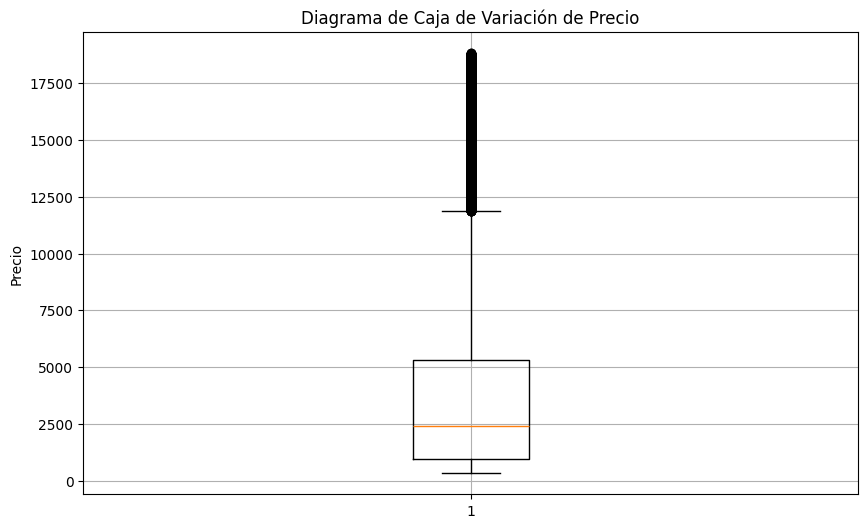

In [8]:
#Creamos el gráfico de caja
plt.figure(figsize=(10, 6))
plt.boxplot(df['price'])
plt.title('Diagrama de Caja de Variación de Precio')
plt.ylabel('Precio')
plt.grid(True)
plt.show()

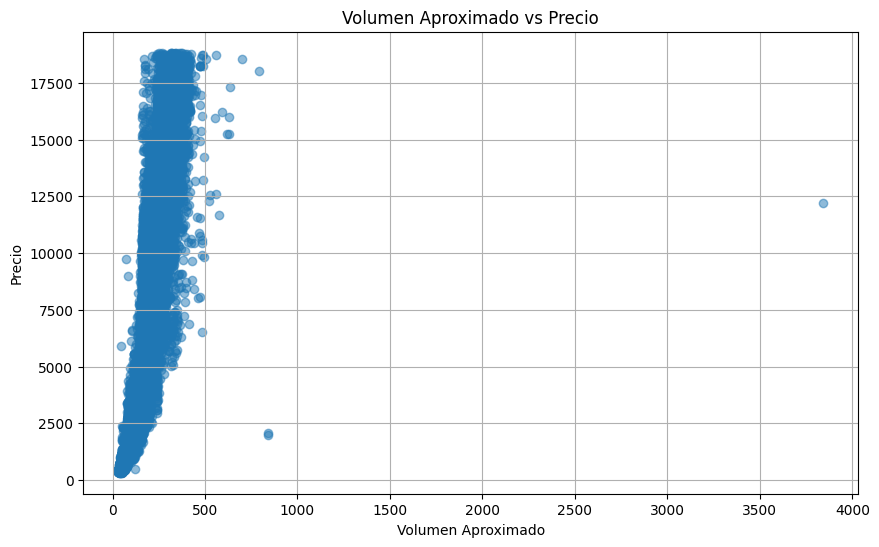

In [9]:
#Creamos el grafico de dispersión
plt.figure(figsize=(10, 6))
plt.scatter(df['volumen_aprox'], df['price'], alpha=0.5)
plt.title('Volumen Aproximado vs Precio')
plt.xlabel('Volumen Aproximado')
plt.ylabel('Precio')
plt.grid(True)
plt.show()

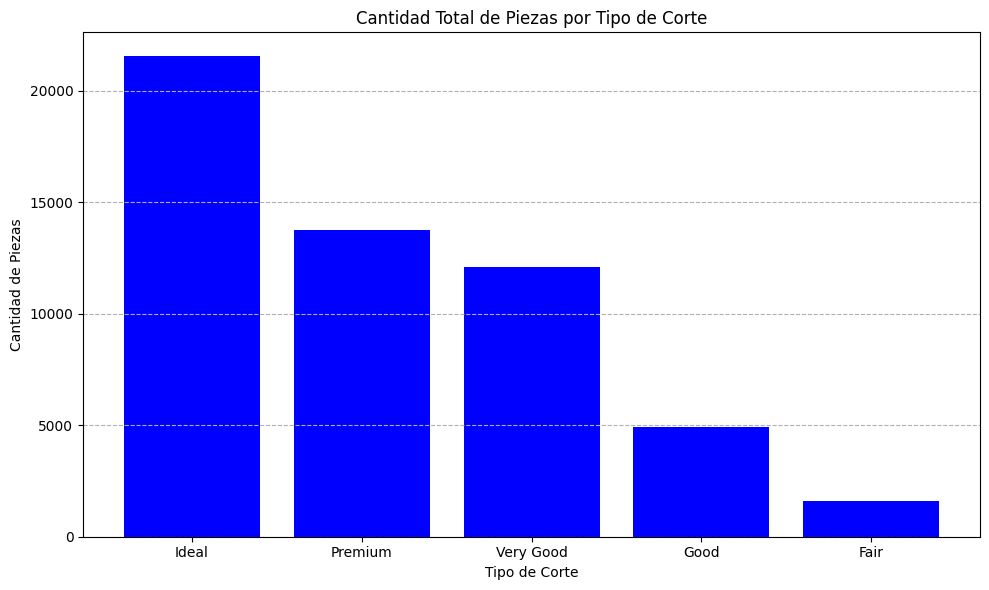

In [12]:
# Contamos las ocurrencias de cada tipo de corte
cortes = df['cut'].value_counts()

# Creamos el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(cortes.index, cortes.values, color='blue')
plt.title('Cantidad Total de Piezas por Tipo de Corte')
plt.xlabel('Tipo de Corte')
plt.ylabel('Cantidad de Piezas')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()